# Create Data Splits for Training, Validation, and Testing

Author: Pete King

This notebook creates a separate dataset to hold in reserve for a final evaluation of our selected model's ability to generalize to unseen data (the "test" set), a dataset for model validation and hyperparameter tuning (the "validation" set), and a dataset for model training (the "training" set).

We want to rigorously test our final model against a period of dynamic real-world volatility.  For example, beginning in October 2024 would capture an initial period of relatively low volatility, followed by the highly volatility period after President Trump announced reciprocal tarrifs in April 2025.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import pandas as pd

import data_prep as dp

In [2]:
# Select the data files and start dates for validation and testing
ETF_FILENAME = 'etf_transformed.csv'
FRED_FILENAME = 'fred_transformed.csv'
INDICIES_FILENAME = 'indicies_transformed.csv'
VALIDATION_START_DATE = '2023-01-01'
TESTING_START_DATE = '2024-10-01'
# Depending on how we calculate our target variables, we may need a buffer
# between training and testing sets.
BUFFER_SIZE = 21  # Number of business days between splits

In [3]:
# Import feature datasets
etf_df = pd.read_csv(
    ETF_FILENAME,
    index_col='date',
    parse_dates=True
)
fred_df = pd.read_csv(
    FRED_FILENAME,
    index_col='date',
    parse_dates=True
)
indicies_df = pd.read_csv(
    INDICIES_FILENAME,
    index_col='date',
    parse_dates=True
)

In [4]:
# Examine starting dates for ETF data - we want to go back to 2004
dp.get_start_dates(etf_df)[-20:]

[('BND_ret-target', Timestamp('2007-04-10 00:00:00')),
 ('BND_vol-target', Timestamp('2007-04-10 00:00:00')),
 ('BND_ret', Timestamp('2007-04-11 00:00:00')),
 ('HYG_ret-target', Timestamp('2007-04-11 00:00:00')),
 ('HYG_vol-target', Timestamp('2007-04-11 00:00:00')),
 ('HYG_ret', Timestamp('2007-04-12 00:00:00')),
 ('BND_ret-h', Timestamp('2007-04-24 00:00:00')),
 ('BND_vol-h', Timestamp('2007-04-24 00:00:00')),
 ('HYG_ret-h', Timestamp('2007-04-25 00:00:00')),
 ('HYG_vol-h', Timestamp('2007-04-25 00:00:00')),
 ('BIL_ret-target', Timestamp('2007-05-30 00:00:00')),
 ('BIL_vol-target', Timestamp('2007-05-30 00:00:00')),
 ('BIL_ret', Timestamp('2007-05-31 00:00:00')),
 ('BIL_ret-h', Timestamp('2007-06-13 00:00:00')),
 ('BIL_vol-h', Timestamp('2007-06-13 00:00:00')),
 ('XLRE_ret-target', Timestamp('2015-10-08 00:00:00')),
 ('XLRE_vol-target', Timestamp('2015-10-08 00:00:00')),
 ('XLRE_ret', Timestamp('2015-10-09 00:00:00')),
 ('XLRE_ret-h', Timestamp('2015-10-22 00:00:00')),
 ('XLRE_vol-h'

In [5]:
# We may want to drop a few ETFs whose price histories don't go back to 2004
"""
etf_df = etf_df.drop(
    columns=['BND_ret', 'BND_h-vol', 'BND_ret_target', 'BND_f-vol_target',
             'HYG_ret', 'HYG_h-vol', 'HYG_ret_target', 'HYG_f-vol_target',
             'BIL_ret', 'BIL_h-vol', 'BIL_ret_target', 'BIL_f-vol_target',
             'XLRE_ret', 'XLRE_h-vol', 'XLRE_ret_target', 'XLRE_f-vol_target'
            ]
).copy()
""";

In [6]:
# Examine starting dates for FRED data - we want to go back to 2004
dp.get_start_dates(fred_df)[-5:]

[('thirty_year_yield_diff', Timestamp('1977-02-16 00:00:00')),
 ('three_month_yield_diff', Timestamp('1981-09-02 00:00:00')),
 ('six_month_yield_diff', Timestamp('1981-09-02 00:00:00')),
 ('one_month_yield_diff', Timestamp('2001-08-01 00:00:00')),
 ('producer_price_index_chg', Timestamp('2009-12-01 00:00:00'))]

In [7]:
# Since the PPI only goes back to 2009, we may want to drop it from the data.
# macro_df = macro_df.drop(columns=['producer_price_index']).copy()

In [8]:
# Merge the FRED and indicies datasets to the ETF data
# IMPORTANT: We join on the ETF index to include only business days
# This is necessary for future volatility calculations based on business days
etf_fred_df = pd.merge(
    left=etf_df,
    right=fred_df,
    how='left',
    left_index=True,
    right_index=True
)
complete_df = pd.merge(
    left=etf_fred_df,
    right=indicies_df,
    how='left',
    left_index=True,
    right_index=True
)

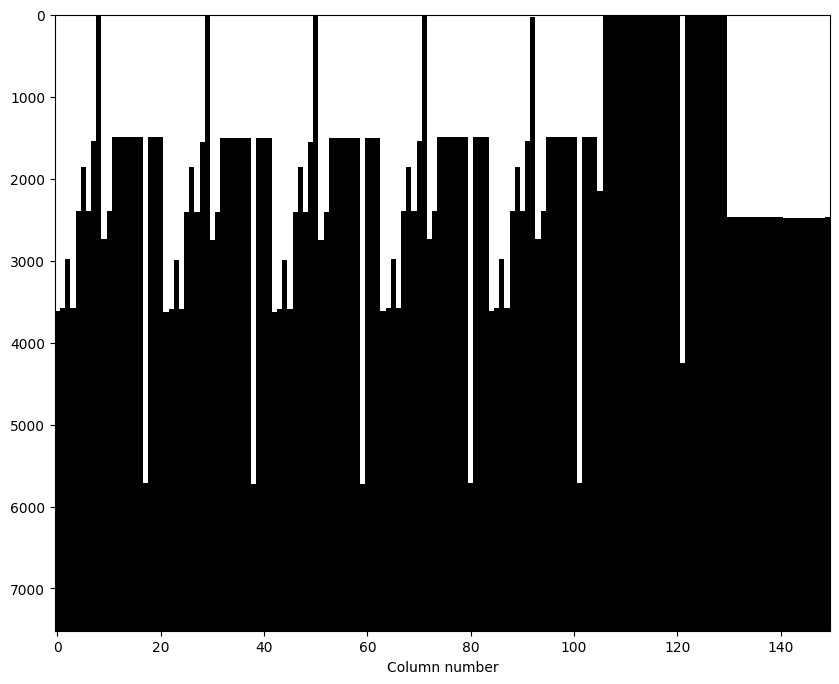

In [9]:
# Create separate training/validation and testing data files
train_val_df, test_df = dp.time_series_split(
    complete_df, TESTING_START_DATE, BUFFER_SIZE
)
train_df, val_df = dp.time_series_split(
    train_val_df, VALIDATION_START_DATE, BUFFER_SIZE
)
dp.view_nan(train_df);

In [10]:
# Drop NA rows from the training DF so we have a common start date
train_df = train_df.dropna().copy()
train_df

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,^HSI_ret,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff
date,,,,,,,,,,,,,,,,,,,,,
2015-10-22,0.000000,0.001704,-0.000358,0.000351,0.001018,0.008755,0.002129,0.020164,0.016753,0.003416,...,-0.003143,0.000588,0.020549,0.007308,0.012288,0.015393,0.006637,0.007860,0.008582,-0.0050
2015-10-23,0.000000,-0.002557,-0.001703,0.003501,-0.005659,0.009802,-0.003664,0.027598,0.010902,-0.001437,...,0.013330,0.000643,0.021230,0.006637,0.009267,0.020494,0.007144,0.008588,0.009448,0.0580
2015-10-26,-0.000219,0.001097,-0.000628,-0.001049,0.002601,-0.006843,0.001791,0.000621,-0.002461,-0.000270,...,-0.001543,0.000639,0.014019,0.006290,0.009302,0.038293,0.006919,0.008600,0.008660,-0.0250
2015-10-27,0.000000,0.000244,0.002241,-0.003271,0.002503,-0.011011,0.000255,0.002036,-0.001934,0.002246,...,0.001145,0.000639,0.014824,0.006285,0.008545,0.038283,0.007235,0.008362,0.008474,-0.0300
2015-10-28,0.000000,-0.002804,-0.008091,0.002688,-0.005197,0.028756,-0.003925,0.008278,0.011310,-0.005037,...,-0.008077,0.000614,0.024452,0.005689,0.007694,0.039257,0.007203,0.009030,0.008559,0.0640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,0.000000,0.000000,0.000858,-0.001997,-0.000309,0.002104,0.001021,-0.006600,-0.000224,-0.000930,...,-0.004957,0.000764,0.024814,0.004327,0.014743,0.036885,0.004887,0.006989,0.016483,-0.0075
2022-11-28,0.000109,-0.001241,-0.007935,-0.010588,0.000412,-0.020359,-0.007264,-0.014782,-0.016086,-0.002329,...,-0.015809,0.000718,0.022503,0.004753,0.012602,0.039479,0.003977,0.008063,0.016381,0.0120
2022-11-29,0.000327,-0.003732,0.004928,0.004302,-0.004229,0.002910,-0.004966,-0.007598,-0.001719,-0.004299,...,0.051091,0.000657,0.022514,0.004985,0.012653,0.045750,0.004235,0.007599,0.019170,0.0450


In [11]:
val_df

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,^HSI_ret,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff
date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,0.000110,0.005276,0.008336,0.001900,0.007800,-0.005521,0.006900,-0.006783,-0.004219,0.003564,...,0.018228,0.000879,0.020851,0.009018,0.008023,0.075598,0.007644,0.010158,0.012124,-0.086
2023-01-04,-0.000110,0.005661,0.009368,0.011456,0.007637,0.012380,0.007227,0.004753,0.007691,0.000655,...,0.031651,0.000848,0.026809,0.009284,0.008130,0.066839,0.007651,0.010032,0.015641,-0.084
2023-01-05,0.000328,-0.001102,-0.012530,-0.002012,-0.001440,-0.010767,-0.000748,-0.015778,-0.011479,0.000281,...,0.012382,0.000950,0.026784,0.008439,0.010383,0.069990,0.007900,0.010689,0.015555,0.011
2023-01-06,-0.000109,0.010966,0.018535,0.014134,0.012787,0.022207,0.016245,0.027227,0.022673,0.009124,...,-0.002879,0.001502,0.025225,0.009823,0.012735,0.069995,0.006386,0.011978,0.015543,-0.151
2023-01-09,0.000219,0.002723,0.002243,0.003568,0.002538,0.001688,0.003952,0.006452,-0.000567,0.002314,...,0.018722,0.001522,0.025283,0.008534,0.014779,0.068986,0.006361,0.011061,0.014328,-0.052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.000109,-0.001071,0.003184,-0.002017,-0.001228,0.000318,-0.001249,-0.009756,-0.002387,0.000091,...,0.010541,0.001421,0.022678,0.008983,0.011213,0.032364,0.005283,0.009435,0.009005,0.011
2024-08-27,0.000218,0.000000,0.002703,0.000631,-0.000410,-0.007787,-0.000804,0.002983,0.001372,0.000000,...,0.004257,0.001344,0.022995,0.008969,0.011205,0.032928,0.005206,0.007833,0.009032,0.015
2024-08-28,0.000109,-0.000670,-0.007052,-0.000505,-0.000512,-0.006789,-0.002057,-0.011412,-0.005822,-0.000091,...,-0.010247,0.001344,0.022711,0.008463,0.012903,0.031574,0.004901,0.007968,0.009530,0.008


In [12]:
test_df

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,^HSI_ret,SHY_vol-h,CL=F_vol-h,GC=F_vol-h,HG=F_vol-h,NG=F_vol-h,^FTSE_vol-h,^GSPC_vol-h,^HSI_vol-h,^TNX_diff
date,,,,,,,,,,,,,,,,,,,,,
2024-10-01,0.000230,0.002947,0.010437,-0.000501,0.003632,-0.013675,0.004795,-0.014030,-0.008999,0.003275,...,0.030524,0.000920,0.017847,0.007492,0.016156,0.047944,0.006647,0.006608,0.025394,-0.059
2024-10-02,0.000109,-0.001866,0.000204,0.000125,-0.002856,-0.001378,-0.002213,0.001412,0.000422,-0.000904,...,0.029620,0.000916,0.017845,0.007829,0.016590,0.047641,0.006314,0.006544,0.026883,0.042
2024-10-03,0.000218,-0.004411,-0.000692,-0.002381,-0.005120,-0.006732,-0.006489,-0.000747,-0.001830,-0.004258,...,-0.014823,0.000971,0.023440,0.007630,0.017471,0.047703,0.005638,0.003843,0.027110,0.065
2024-10-04,0.000219,-0.006586,-0.001998,-0.001130,-0.009697,0.013876,-0.005455,0.011828,0.009046,-0.006833,...,0.027799,0.001442,0.023613,0.006710,0.017527,0.048010,0.004193,0.004729,0.028177,0.131
2024-10-07,0.000219,-0.002971,-0.003394,-0.004281,-0.003635,-0.007879,-0.005124,-0.010769,-0.009081,-0.001098,...,0.015835,0.001502,0.025355,0.006664,0.017520,0.044161,0.004129,0.005555,0.028618,0.045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,0.000328,-0.008031,-0.031034,-0.009333,-0.009023,-0.022089,-0.012348,-0.018655,-0.014440,-0.008042,...,-0.008794,0.001199,0.058060,0.023734,0.016870,0.030309,0.011384,0.009391,0.012392,0.110
2026-03-23,0.000109,0.003819,-0.022853,0.006567,0.003157,0.021362,0.006562,0.010153,0.010445,-0.000272,...,-0.036043,0.001276,0.066289,0.026254,0.017644,0.036602,0.011358,0.009712,0.016275,-0.057
2026-03-24,0.000109,-0.002590,0.000223,-0.003405,-0.003368,0.005360,-0.002029,-0.006860,-0.003362,-0.003272,...,0.027557,0.001343,0.054726,0.024853,0.016763,0.035572,0.010455,0.009760,0.017167,0.058


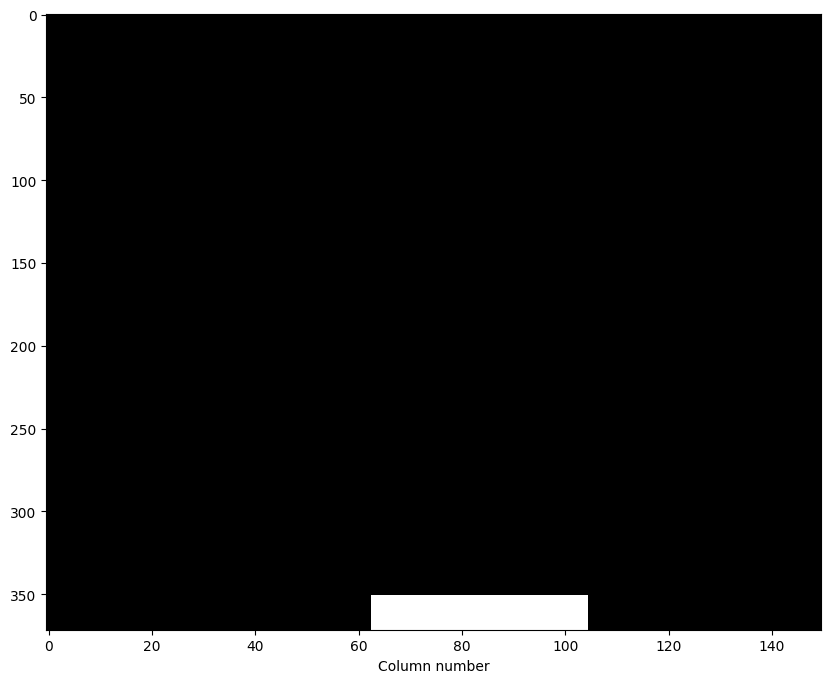

In [13]:
dp.view_nan(test_df);

In [14]:
# Drop NA rows from the testing DF where some return data is missing at the end
test_df = test_df.dropna().copy()

In [15]:
# Get column names for breaking out separate datasets by type
etf_cols = [column for column in etf_df.columns]
fred_cols = [column for column in fred_df.columns]
indicies_cols = [column for column in indicies_df.columns]

In [16]:
DATA_FOLDER  = 'data/train-val-test/'
# Save complete segmented datasets
train_df.to_csv(DATA_FOLDER + 'train_ALL_DATA.csv')
val_df.to_csv(DATA_FOLDER + 'val_ALL_DATA.csv')
test_df.to_csv(DATA_FOLDER + 'test_ALL_DATA.csv')

# Save ETF datasets
train_df[etf_cols].to_csv(DATA_FOLDER + 'train_etf_data.csv')
val_df[etf_cols].to_csv(DATA_FOLDER + 'val_etf_data.csv')
test_df[etf_cols].to_csv(DATA_FOLDER + 'test_etf_data.csv')

# Save FRED datasets
train_df[fred_cols].to_csv(DATA_FOLDER + 'train_fred_data.csv')
val_df[fred_cols].to_csv(DATA_FOLDER + 'val_fred_data.csv')
test_df[fred_cols].to_csv(DATA_FOLDER + 'test_fred_data.csv')

# Save index datasets
train_df[indicies_cols].to_csv(DATA_FOLDER + 'train_indicies_data.csv')
val_df[indicies_cols].to_csv(DATA_FOLDER + 'val_indicies_data.csv')
test_df[indicies_cols].to_csv(DATA_FOLDER + 'test_indicies_data.csv')